In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
df = pd.read_csv("C:/Users/pinki/OneDrive/Desktop/Data_science(infosis)/datascience_steps_daywise/machine_learning/Real estate.csv")
df 

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [4]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [5]:
features = [ 'X2 house age','X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',

]
target =  'Y house price of unit area'


In [6]:
X =df[features]
Y = df[target ]

In [33]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1
)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [35]:
# (Xi - mean) / sd
# fit_transform -> (fit) Learning and (transform) Implement
# Learning -> calculation of mean and sd
# Implement -> (Xi - mean) / sd
X_train_scale = scaler.fit_transform(X_train)

# Implement -> (Xi - mean) / sd
X_test_scale = scaler.transform(X_test)

# define model

In [36]:
model = LinearRegression()
# fit data into model
# fit feature scaled training record and target training record
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
Y_pred = model.predict(X_test_scale)
Y_pred

array([33.07996225, 47.80869225, 22.11373816, 15.13096266, 44.6259416 ,
       33.34343735, 31.19940423, 44.33327931, 39.97905651, 12.34608693,
       13.8395669 , 39.23834498, 30.78835143, 45.73299058, 52.39244171,
       34.0245196 , 44.6259416 , 43.13136871, 31.475026  , 46.30046212,
       52.58815104, 29.97317982, 40.69807579, 48.86155195, 46.10788025,
       28.72708906, 34.00302145, 45.51555296, 47.95300422, 14.53618299,
       35.830845  , 35.24661163, 40.78115048, 45.61532743, 48.63792301,
       14.1309192 , 41.07859656, 40.65344242, 38.5988199 , 15.05613181,
       41.92880337, 25.42152773, 52.21783639, 34.88185988, 33.64942531,
       39.47780571, 32.82670042, 41.10007362, 44.07963274, 34.27966577,
       14.15586281, 43.05867842, 48.10381014, 15.2844915 , 51.29462089,
       43.87893238, 44.6259416 , 39.2943165 , 40.7370706 , 42.33569508,
       25.39313138, 41.71660439, 33.97016178, 14.1309192 , 40.50311433,
       44.32122364, 39.34067446, 45.5714346 , 15.30943512, 39.67

# metrics

In [38]:
rmse = np.sqrt(mean_squared_error(Y_test,Y_pred))
r2 = r2_score(Y_test,Y_pred) 


In [39]:
print(f'mean_squared_error_value :{rmse}')
print(f'RMSE in %: {rmse/414} (Error rate)')
print(f'r2_score value is  : {r2}')


mean_squared_error_value :6.7397916306529
RMSE in %: 0.016279689929113286 (Error rate)
r2_score value is  : 0.700731455305317


# visualization

In [40]:
min_val = min(Y_train.min(),Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
print(min_val)
print(max_val)


7.6
59.6


Text(0, 0.5, 'Predicted House Prices')

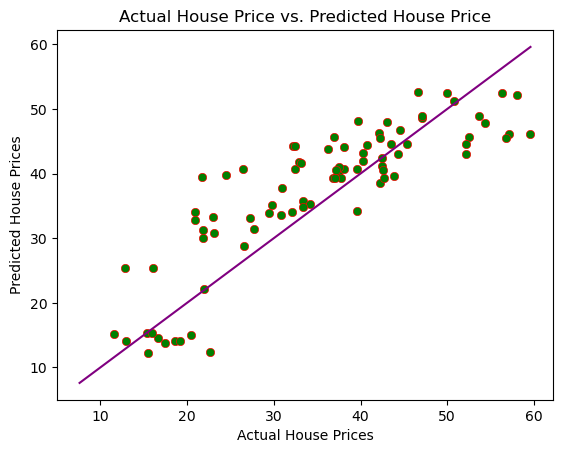

In [41]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.scatterplot(x= Y_test,y = Y_pred,color = 'green',edgecolor = 'red')
plt.plot([min_val, max_val],[min_val, max_val],color='purple')
plt.title('Actual House Price vs. Predicted House Price')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')



### Predict in new data

In [16]:
input_data = {
    'X2 house age': [20, 5, 11],
    'X3 distance to the nearest MRT station': [20.4, 85.0, 11.2],
    'X4 number of convenience stores': [3, 0, 4], 
    'X5 latitude': [24.98298, 24.96108, 24.95593], 
    'X6 longitude': [121.51254, 121.53913, 121.54348]
}

In [17]:
X_new = pd.DataFrame(input_data)
print('-'*135)
print(X_new.to_markdown(numalign='center', stralign='center'))
print('-'*135)


---------------------------------------------------------------------------------------------------------------------------------------
|    |  X2 house age  |  X3 distance to the nearest MRT station  |  X4 number of convenience stores  |  X5 latitude  |  X6 longitude  |
|:--:|:--------------:|:----------------------------------------:|:---------------------------------:|:-------------:|:--------------:|
| 0  |       20       |                   20.4                   |                 3                 |    24.983     |    121.513     |
| 1  |       5        |                    85                    |                 0                 |    24.9611    |    121.539     |
| 2  |       11       |                   11.2                   |                 4                 |    24.9559    |    121.543     |
---------------------------------------------------------------------------------------------------------------------------------------


In [18]:
X_new_scale = scaler.transform(X_new)
X_new_scale


array([[ 0.2397118 , -0.85454639, -0.38824102,  1.0947738 , -1.42748297],
       [-1.08652967, -0.80142526, -1.40545298, -0.66209254,  0.35073175],
       [-0.55603308, -0.86211163, -0.04917037, -1.07523691,  0.64163939]])

In [19]:
Y_new_pred = model.predict(X_new_scale)
Y_new_pred


array([44.85564495, 39.49905765, 41.31209645])

In [20]:
X_new['predicted house price'] = Y_new_pred


In [21]:
X_new
print('-'*135)
print(X_new.to_markdown(numalign = 'center',stralign = 'center'))
print('-'*135)

---------------------------------------------------------------------------------------------------------------------------------------
|    |  X2 house age  |  X3 distance to the nearest MRT station  |  X4 number of convenience stores  |  X5 latitude  |  X6 longitude  |  predicted house price  |
|:--:|:--------------:|:----------------------------------------:|:---------------------------------:|:-------------:|:--------------:|:-----------------------:|
| 0  |       20       |                   20.4                   |                 3                 |    24.983     |    121.513     |         44.8556         |
| 1  |       5        |                    85                    |                 0                 |    24.9611    |    121.539     |         39.4991         |
| 2  |       11       |                   11.2                   |                 4                 |    24.9559    |    121.543     |         41.3121         |
------------------------------------------------------

# extras

# model_selection

In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train_scale,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = model.predict(X_test_scale)

# metrics

In [42]:
rmse =np.sqrt(mean_squared_error(Y_test,y_pred))
r2 = r2_score(Y_test,y_pred)

In [47]:
print(f'rmse :{rmse}')
print(f'R2 :{r2}') 
print(f'rmse in %: {rmse/414*100:.2f}% (Error rate)')

rmse :16.923493747658483
R2 :-0.8868969495186894
rmse in %: 4.09% (Error rate)


##  visualization by using scatter plot

In [31]:
min_val = min(Y_test.min(),Y_train.min())
max_val = max(Y_test.max(),Y_train.max())

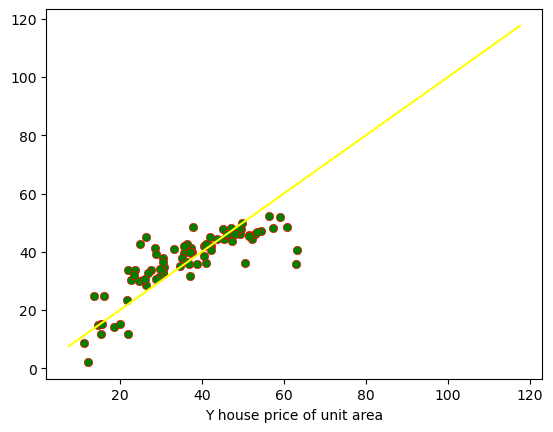

In [ ]:
sns.scatterplot(x= Y_test,y = y_pred,color = 'green',edgecolor = 'red'  )
plt.plot([min_val,max_val],[min_val,max_val],color = 'yellow')
plt.title()